# **Taller 3: Lectura de Datos y mínimos cuadrados en Fortran**
Juan Manuel Rosero García - 2437715

In [ ]:
from google.colab import files

# Importa el archivo 100_mediciones_pendulo_minimos_cuadrados.xlsx
# Y también el archivo script_limpieza_pendulo_estudiantes.py
# Por favor y si no es mucha molestia :D aunque es necesario si quiere que el código funcione :v
archivos_cargados = files.upload()
print("Archivos cargados correctamente:", list(archivos_cargados.keys()))

Archivos cargados correctamente: []


In [ ]:
#Ejecutamos el código de python para la limpieza de datos
!python script_limpieza_pendulo_estudiantes.py


Número inicial de registros: 100

Primeras mediciones:
   medicion_id  longitud_cm  ...  calidad_video  observacion_campo
0            1           55  ...           Alta                NaN
1            2           90  ...           Alta                NaN
2            3           40  ...           Alta                NaN
3            4           75  ...           Alta                NaN
4            5           25  ...           Alta                NaN

[5 rows x 8 columns]

Longitudes potencialmente sospechosas:
Empty DataFrame
Columns: [medicion_id, longitud_cm, observacion_campo]
Index: []

Períodos potencialmente sospechosos:
Empty DataFrame
Columns: [medicion_id, longitud_cm, numero_oscilaciones, tiempo_medido_s, periodo_preliminar_s, observacion_campo]
Index: []

Mediciones con calidad de video baja:
    medicion_id calidad_video                                observacion_campo
35           36          Baja  Se perdió temporalmente el marcador en el video
76           77        

In [ ]:
!which gfortran || (apt-get update -qq && apt-get install -y gfortran)
!gfortran --version | head -n 1

/usr/bin/gfortran
GNU Fortran (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0


In [ ]:
%%writefile ajuste_pendulo.f90
program ajuste_pendulo
  ! ------------
  ! Variables
  ! ------------
  use, intrinsic :: iso_fortran_env, only: real64, iostat_end  ! Precisión y código de fin de archivo
  implicit none                                               ! Evita variables implícitas

  ! Control del archivo y campos enteros
  integer :: unidad, unidad_salida, estado, id, n_osc, n_datos

  ! Campos reales y variables transformadas x, y
  real(real64) :: longitud_cm, angulo_deg, tiempo_s, periodo_s
  real(real64) :: x, y
  ! Para el inciso 5, las sumatorias
  real(real64) :: sx, sy, sxx, sxy, syy
  !Para el inciso 6, pendiente e intercepto
  real(real64) :: m, b, den, g, r2
  real(real64), parameter :: PI = 3.14159265358979323846_real64

  ! ------------
  ! Ciclos y cálculos previos
  ! ------------

  ! Inciso 1: Abre el archivo existente
  open(newunit=unidad, file='pendulo_limpio.dat', status='old', &
       action='read', iostat=estado)

  if (estado /= 0) error stop 'No fue posible abrir el archivo'  ! Verifica la apertura


  ! Dejo las variables en 0 para que no se acumulen en el inciso 5
  n_datos = 0
  sx  = 0.0_real64
  sy  = 0.0_real64
  sxx = 0.0_real64
  sxy = 0.0_real64
  syy = 0.0_real64

  write(*, '(A)') '  ID   L (m)      T (s)      x = L (m)   y = T² (s²)'

  ! Inciso 2: El número de filas es desconocido; se lee hasta encontrar el final
  do
     read(unidad, *, iostat=estado) id, longitud_cm, angulo_deg, &
          n_osc, tiempo_s

     if (estado == iostat_end) exit                         ! Fin normal del archivo
     if (estado /= 0) error stop 'Hay una fila mal formada'  ! Otro valor indica error

     ! Inciso 3: Conversión de longitud a metros y cálculo del período
     periodo_s = tiempo_s / real(n_osc, real64)

     ! Inciso 4: Definición de las variables linealizadas x = L, y = T²
     x = longitud_cm / 100.0_real64
     y = periodo_s**2

     ! Inciso 5: Acumular las sumatorias en cada paso del ciclo
     sx  = sx + x
     sy  = sy + y
     sxx = sxx + x**2
     sxy = sxy + x * y
     syy = syy + y**2

     n_datos = n_datos + 1  ! Cuenta la fila aceptada

     ! Muestra los primeros datos transformados en pantalla
     print '(I4, 4F12.4)', id, x, periodo_s, x, y
  end do

  close(unidad)  ! Libera el archivo

if (n_datos < 2) error stop 'Error: Se requieren al menos dos datos para realizar el ajuste.'
! 3. Denominador nulo en la fórmula de mínimos cuadrados

  ! ------------
  ! Cálculos
  ! ------------

  ! Inciso 6: Cálculo de la pendiente (m) e intercepto (b) por mínimos cuadrados
  den = real(n_datos, real64) * sxx - sx**2
  m = (real(n_datos, real64) * sxy - sx * sy) / den
  b = (sy * sxx - sx * sxy) / den

  ! Inciso 7: Cálculo de la aceleración de la gravedad g = 4*pi^2 / m
  g = (4.0_real64 * PI**2) / m

  ! Inciso 8: Coeficiente de determinación R^2
  r2 = ((real(n_datos, real64) * sxy - sx * sy)**2) / &
       ((real(n_datos, real64) * sxx - sx**2) * (real(n_datos, real64) * syy - sy**2))

  ! ------------
  ! Imprimiendo los resultados
  ! ------------


  print *, 'Sx  =', sx
  print *, 'Sy  =', sy
  print *, 'Sxx =', sxx
  print *, 'Sxy =', sxy

  print *, '==========================================='
  print *, '       RESULTADOS DEL AJUSTE LINEAL        '
  print *, '==========================================='
  print '(A, I0)',        'Número de datos aceptados (N) = ', n_datos
  print '(A, F12.6, A)', 'Pendiente (a)                 = ', m, ' s²/m'
  print '(A, F12.6, A)', 'Intercepto (b)                = ', b, ' s²'
  print '(A, F12.6)',    'Coeficiente R²                = ', r2
  print '(A, F12.6, A)', 'Gravedad estimada (g)         = ', g, ' m/s²'
  print *, '==========================================='

! Inciso 10: Escritura en archivo resultados_ajuste.dat
open(newunit=unidad_salida, file='resultados_ajuste.dat', &
      status='replace', action='write')
write(unidad_salida, *) n_datos, m, b, r2, g
close(unidad_salida)

end program ajuste_pendulo

Overwriting ajuste_pendulo.f90


In [ ]:
!gfortran -std=f2008 -Wall -Wextra -fcheck=all -o ajuste_pendulo ajuste_pendulo.f90
!./ajuste_pendulo

  ID   L (m)      T (s)      x = L (m)   y = T² (s²)
   1      0.5500      1.4975      0.5500      2.2425
   2      0.9000      1.9135      0.9000      3.6615
   3      0.4000      1.2629      0.4000      1.5949
   4      0.7500      1.7416      0.7500      3.0332
   5      0.2500      0.9934      0.2500      0.9868
   6      0.6000      1.5619      0.6000      2.4395
   7      0.9500      1.9764      0.9500      3.9062
   8      0.4500      1.3443      0.4500      1.8071
   9      0.8000      1.7972      0.8000      3.2299
  10      0.3000      1.1057      0.3000      1.2226
  11      0.8000      1.7980      0.8000      3.2328
  13      0.6500      1.6257      0.6500      2.6429
  14      1.0000      2.0006      1.0000      4.0024
  15      0.5000      1.4232      0.5000      2.0255
  16      0.8500      1.8587      0.8500      3.4548
  17      0.3500      1.1842      0.3500      1.4023
  19      0.2000      0.8992      0.2000      0.8086
  20      0.5500      1.4953      0.5500      

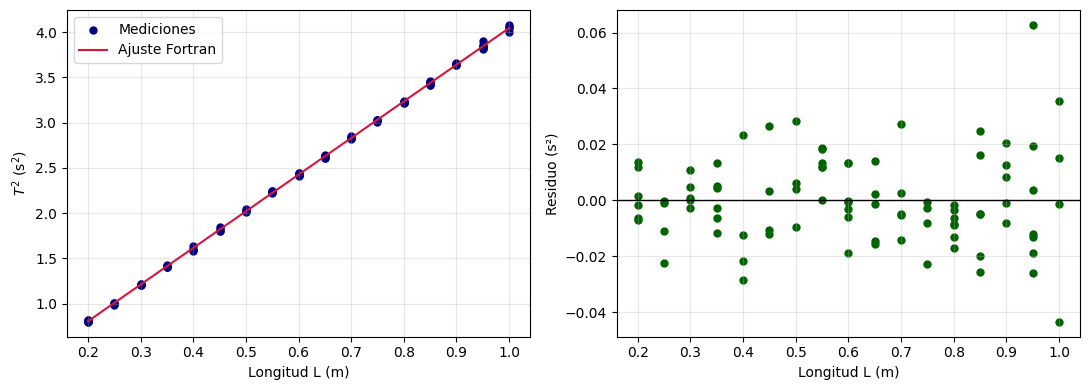

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Lee las cinco columnas producidas por el script de limpieza
datos = np.loadtxt("pendulo_limpio.dat")
longitud_m = datos[:, 1] / 100.0
numero_oscilaciones = datos[:, 3]
tiempo_total_s = datos[:, 4]

# TODO: construya las variables linealizadas x=L y y=T^2
periodo_s = tiempo_total_s / numero_oscilaciones
x = longitud_m
y = periodo_s**2

# Copie los parámetros calculados por su programa Fortran
a = 4.048735
b = -0.002888

# Ordena x para dibujar una línea continua de izquierda a derecha
orden = np.argsort(x)
y_ajustada = a*x + b
residuos = y - y_ajustada

# Primer panel: mediciones y recta. Segundo panel: residuos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(x, y, s=25, color="navy", label="Mediciones")
ax1.plot(x[orden], y_ajustada[orden], color="crimson", label="Ajuste Fortran")
ax1.set_xlabel("Longitud L (m)")
ax1.set_ylabel(r"$T^2$ (s$^2$)")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.axhline(0.0, color="black", linewidth=1)
ax2.scatter(x, residuos, s=25, color="darkgreen")
ax2.set_xlabel("Longitud L (m)")
ax2.set_ylabel("Residuo (s²)")
ax2.grid(alpha=0.3)

plt.tight_layout()
# Guarda la figura que se entregará con el informe
plt.savefig("ajuste_pendulo_y_residuos.png", dpi=200, bbox_inches="tight")

In [ ]:
from pathlib import Path
import numpy as np

# Función auxiliar que imprime un veredicto uniforme para cada prueba
resultados_pruebas = []

def informar(nombre, condicion, detalle=""):
    estado = "PASS" if condicion else "FAIL"
    print(f"{estado:<4}  {nombre}{detalle}")
    resultados_pruebas.append(bool(condicion))
    return bool(condicion)

# Archivos que debe producir el flujo de trabajo completo
archivo_datos = Path("pendulo_limpio.dat")
archivo_resultados = Path("resultados_ajuste.dat")
archivo_figura = Path("ajuste_pendulo_y_residuos.png")

# Primer nivel: comprueba existencia antes de intentar leer
ok_datos = informar("Existe pendulo_limpio.dat", archivo_datos.exists())
ok_resultados = informar("Existe resultados_ajuste.dat", archivo_resultados.exists())
informar("Existe la figura", archivo_figura.exists() and archivo_figura.stat().st_size > 0 if archivo_figura.exists() else False)

# Segundo nivel: valida formatos y compara con un cálculo independiente
if ok_datos and ok_resultados:
    try:
        datos = np.atleast_2d(np.loadtxt(archivo_datos))
        resultados = np.loadtxt(archivo_resultados).reshape(-1)

        estructura_datos = datos.shape[1] == 5 and datos.shape[0] >= 2
        estructura_resultados = resultados.size == 5
        informar("Formato del archivo de datos", estructura_datos, f"  filas={datos.shape[0]}, columnas={datos.shape[1]}")
        informar("Formato del archivo de resultados", estructura_resultados, f"  valores={resultados.size}")

        if estructura_datos and estructura_resultados:
            # Reconstruye x=L y y=T^2 directamente desde los datos limpios
            longitud_m = datos[:, 1] / 100.0
            periodo_s = datos[:, 4] / datos[:, 3]
            x = longitud_m
            y = periodo_s**2
            n_ref = len(x)

            # Calcula los valores de referencia con las fórmulas del método
            sx = np.sum(x)
            sy = np.sum(y)
            sxx = np.sum(x*x)
            sxy = np.sum(x*y)
            den = n_ref*sxx - sx*sx
            a_ref = (n_ref*sxy - sx*sy) / den
            b_ref = (sy - a_ref*sx) / n_ref
            residuos_ref = y - (a_ref*x + b_ref)
            sse_ref = np.sum(residuos_ref**2)
            sst_ref = np.sum((y - np.mean(y))**2)
            r2_ref = 1.0 - sse_ref/sst_ref
            g_ref = 4.0*np.pi**2/a_ref

            # Compara, con tolerancia, cada resultado entregado por Fortran
            n_f, a_f, b_f, r2_f, g_f = resultados
            informar("Número de datos N", int(round(n_f)) == n_ref, f"  obtenido={n_f:g}, esperado={n_ref}")
            informar("Pendiente a", np.isclose(a_f, a_ref, rtol=1e-6, atol=1e-9), f"  obtenida={a_f:.8g}, esperada={a_ref:.8g}")
            informar("Intercepto b", np.isclose(b_f, b_ref, rtol=1e-6, atol=1e-9), f"  obtenido={b_f:.8g}, esperado={b_ref:.8g}")
            informar("Coeficiente R²", np.isclose(r2_f, r2_ref, rtol=1e-6, atol=1e-9), f"  obtenido={r2_f:.8g}, esperado={r2_ref:.8g}")
            informar("Gravedad g", np.isclose(g_f, g_ref, rtol=1e-6, atol=1e-9), f"  obtenida={g_f:.8g}, esperada={g_ref:.8g}")
            informar("Valor físico razonable de g", 7.0 < g_f < 12.0, f"  g={g_f:.5f} m/s²")
    except Exception as error:
        informar("No fue posible completar la verificación", False, f": {error}")

# Resumen que debe copiarse en el informe de una página
n_pass = sum(resultados_pruebas)
n_total = len(resultados_pruebas)
print(f"\nRESUMEN PASS/FAIL: {n_pass} de {n_total} pruebas pasaron.")

PASS  Existe pendulo_limpio.dat
PASS  Existe resultados_ajuste.dat
PASS  Existe la figura
PASS  Formato del archivo de datos  filas=89, columnas=5
PASS  Formato del archivo de resultados  valores=5
PASS  Número de datos N  obtenido=89, esperado=89
PASS  Pendiente a  obtenida=4.0487347, esperada=4.0487347
PASS  Intercepto b  obtenido=-0.0028878571, esperado=-0.0028878571
PASS  Coeficiente R²  obtenido=0.99974782, esperado=0.99974782
PASS  Gravedad g  obtenida=9.7508038, esperada=9.7508038
PASS  Valor físico razonable de g  g=9.75080 m/s²

RESUMEN PASS/FAIL: 11 de 11 pruebas pasaron.
